In [ ]:
# Handwritten digit recognition exercise (zero and one digits)--->binary classification

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from autils import *
%matplotlib inline

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [3]:
#load dataset - contains 1000 training examples with 20*20 pixel grayscale image(400)
# giving a matrix of X(1000 * 400)
X, y = load_data()

In [4]:
#view the variables
print(f'The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [7]:
print(f'The first element of y is: ', y[0,0])
print(f'The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  1


In [8]:
#check dimensions of the variables
print(f'The shape of X is: ' + str(X.shape))
print(f'The shape of y is: ' + str(y.shape))

The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


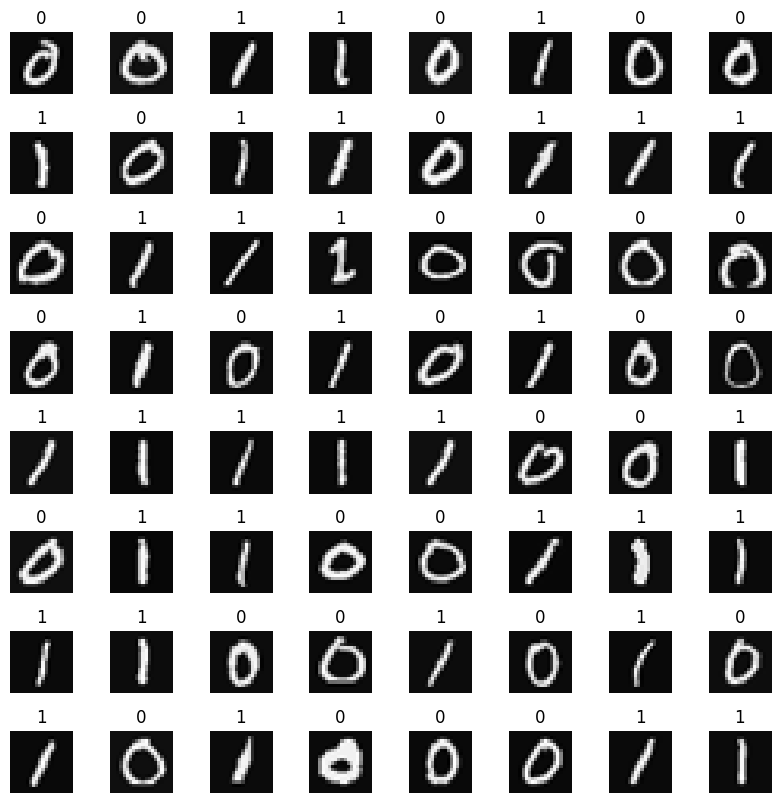

In [9]:
#visualize the data
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m,n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i, ax in enumerate(axes.flat):
    #select random indices
    random_index = np.random.randint(m)

    #select rows corresponding to the randomindices and reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    #display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    #display the label above the image
    ax.set_title(y[random_index, 0])
    ax.set_axis_off()

In [ ]:
'''The parameters have dimensions that are sized for a neural network with  25
  units in layer 1,  15
  units in layer 2 and  1
  output unit in layer 3.
  
Therefore, the shapes of W, and b, are

layer1: The shape of W1 is (400, 25) and the shape of b1 is (25,)
layer2: The shape of W2 is (25, 15) and the shape of b2 is: (15,)
layer3: The shape of W3 is (15, 1) and the shape of b3 is: (1,)
  '''

In [11]:
#model representation
#Tensorflow model implementation
model = Sequential([
    tf.keras.Input(shape=(400,)),  #specifies input size
    Dense(25, activation='sigmoid'),
    Dense(15, activation='sigmoid'),
    Dense(1, activation='sigmoid')
 ],
 name = 'my_model')

In [12]:
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 25)                10025     
                                                                 
 dense_1 (Dense)             (None, 15)                390       
                                                                 
 dense_2 (Dense)             (None, 1)                 16        
                                                                 
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
_________________________________________________________________


In [13]:
#unit tests
from public_tests import *

test_c1(model)

All tests passed!


In [ ]:
#parameter counts
L1_num_params = 400 * 25 + 25   #W1 paramters  + b1 parameters
L2_num_params = 25 * 15 + 15    #W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1   #W3 paramters + b3 parameters

print(f'L1 params = ', L1_num_params, '\nL2 params = ', L2_num_params, '\nL3 params = ', L3_num_params)

L1 params =  10025 
L2 params =  390 
L3 params =  16


In [ ]:
#examine model details by extracting the layers
[layer1, layer2, layer3] = model.layers

In [44]:
#examine weights shapes in numpy
W1, b1 = layer1.get_weights()
W2, b2 = layer2.get_weights()
W3, b3 = layer3.get_weights()
print(f'W1 shape = {W1.shape}, b1 shape = {b1.shape}')
print(f'W2 shape = {W2.shape}, b2 shape = {b2.shape}')
print(f'W3 shape = {W3.shape}, b3 shape = {b3.shape}')

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


In [45]:
#weights in Tensorflow form
print(model.layers[2].weights)

[<tf.Variable 'dense_2/kernel:0' shape=(15, 1) dtype=float32, numpy=
array([[-0.7531946 ],
       [ 0.13180141],
       [-0.8671515 ],
       [ 0.7122263 ],
       [-0.37636116],
       [ 0.58683795],
       [ 0.58701414],
       [ 0.6723133 ],
       [ 0.5033742 ],
       [ 0.40258646],
       [-0.60375255],
       [-0.5332669 ],
       [ 0.41031775],
       [-0.84626365],
       [ 0.6199254 ]], dtype=float32)>, <tf.Variable 'dense_2/bias:0' shape=(1,) dtype=float32, numpy=array([-0.16852705], dtype=float32)>]


In [46]:
#This defines the Loss function and runss gradient descent to fit the weights of the model to the 
# training data

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
) 
model.fit(
    X, y,
    epochs=20
 )

Epoch 1/20
32/32 [==============================] - 1s 2ms/step - loss: 0.0235
Epoch 2/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0190
Epoch 3/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0163
Epoch 4/20
32/32 [==============================] - 0s 3ms/step - loss: 0.0145
Epoch 5/20
32/32 [==============================] - 0s 4ms/step - loss: 0.0131
Epoch 6/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0121
Epoch 7/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0112
Epoch 8/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0103
Epoch 9/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0085
Epoch 10/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0059
Epoch 11/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0049
Epoch 12/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0043
Epoch 13/20
32/32 [==============================

In [47]:
#example to make a prediction
prediction = model.predict(X[0].reshape(1,400))   # a zero
print(f'predicting a zero: {prediction}')
prediction = model.predict(X[500].reshape(1,400))    # a one
print(f'predicting a one: {prediction}')

1/1 [==============================] - 0s 152ms/step
predicting a zero: [[0.00229756]]
1/1 [==============================] - 0s 25ms/step
predicting a one: [[0.99836755]]


In [ ]:
#The output of the model is interpreted as a probability. 
# In the first example above, the input is a zero. The model predicts 
#    the probability that the input is a one is nearly zero. 
# In the second example, the input is a one. The model predicts the probability
#  that the input is a one is nearly one. 
# As in the case of logistic regression, the probability is compared to a threshold to make a final prediction.

In [23]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f'prediction after threshold: {yhat}')

prediction after threshold: 1


1/1 [==============================] - 0s 32ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

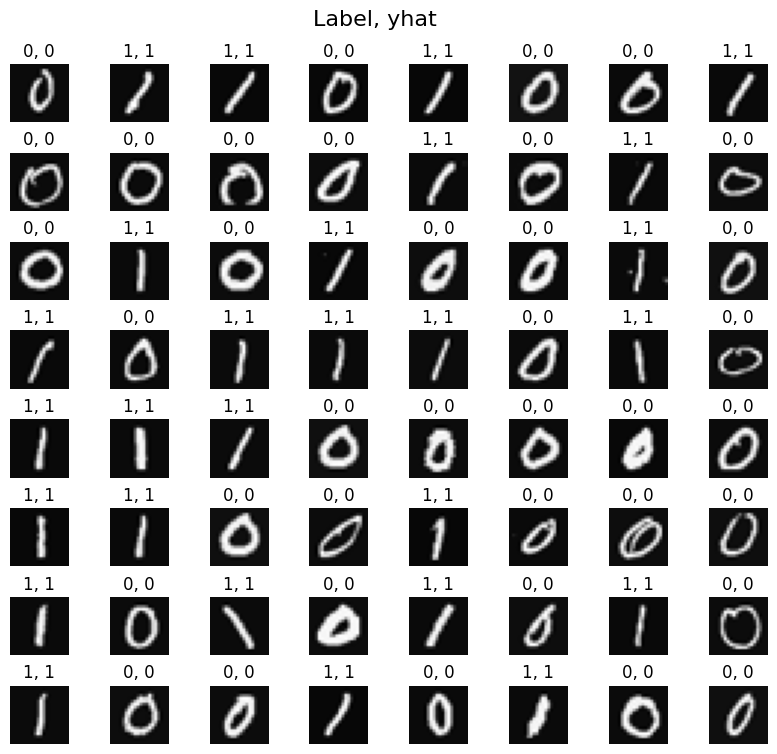

In [26]:
#let's compare the predictions Vs the labels for a random sample of 64 digits

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92])  #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    #select random indices
    random_index = np.random.randint(m)

    #select rows corresponding to the random aindices and reshape the image
    X_random_reshape = X[random_index].reshape((20,20)).T

    #display the image
    ax.imshow(X_random_reshape, cmap='gray')

    #predict using the Nei=ural network
    prediction = model.predict(X[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0

    #display the label above image
    ax.set_title(f'{y[random_index, 0]}, {yhat}')
    ax.set_axis_off()
fig.suptitle('Label, yhat', fontsize=16)
plt.show


In [ ]:
#Numpy model implementation(forwaard propagation in numpy)
# uses a for loop to visit each unit (j) in the layer and perform the dot product 
# of the weights for that unit (W[:,j]) and sum the bias for the unit (b[j]) to form z. 
# An activation function g(z) is then applied to that result.

In [48]:
def my_dense(a_in, W, b, g):
    ''' 
    Computes dense layer

    Args:
     a_in (ndarray (n, )) : Data, 1 example
     W (ndarray (n, )) : Weight matrix, n features per unit, j units
     b (ndarray (j, )) : bias vector, j units
     g activation function(e.g sigmoid)

    Returns:
     a_out (ndarray (j, )) : j units
    '''

    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):
        w = W[:,j]  #select weights for unit j, these are in column j of W
        z = np.dot(a_in, w) + b[j]   #dot product of w and a_in + b
        a_out[j] = g(z)   #apply the activation to z
    return(a_out)

In [49]:
#test the above implementation
x_tst = 0.1*np.arange(1,3,1).reshape(2,)   #1 example with 2 features
W_tst = 0.1*np.arange(1,7,1).reshape(2,3)  #2 input features, 3 output features
b_tst = 0.1*np.arange(1,4,1).reshape(3,)    #3 features
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[0.54735762 0.57932425 0.61063923]


In [50]:
#unit test
test_c2(my_dense)

All tests passed!


In [51]:
#building a 3 layer neural network utilizing `my_dense` function(subroutine)
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x, W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3)

In [52]:
#copy the weights and biases from Tensorflow
W1_tmp, b1_tmp = layer1.get_weights()
W2_tmp, b2_tmp = layer2.get_weights()
W3_tmp, b3_tmp = layer3.get_weights()


In [54]:
#make predictions
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f'yhat = ', yhat, f'label = ', y[0,0])

prediction = my_sequential(X[500], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f'yhat = ', yhat, f'label = ', y[500,0])


yhat =  0 label =  0
yhat =  1 label =  1


1/1 [==============================] - 0s 25ms/step


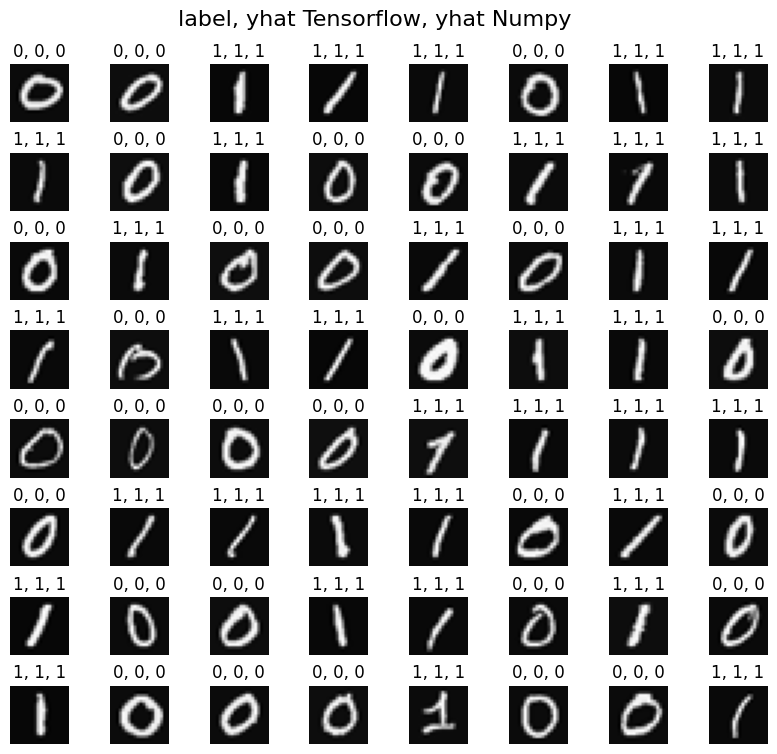

In [58]:
#predictions from n=both Numpy and Tensorflow model
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92])  #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    #select random indices
    random_index = np.random.randint(m)

    #select rows corresponding to the random indices and reshape the image
    X_random_reshaped = X[random_index].reshape((20, 20)).T

    #display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    #predict using the neural network implemented in numpy
    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
    my_yhat = int(my_prediction >= 0.5)

    #predict using the neural network implemented in tensorflow
    tf_prediction = model.predict(X[random_index].reshape(1, 400))
    tf_yhat = int(tf_prediction >= 0.5)

    #display the above image
    ax.set_title(f'{y[random_index,0]}, {tf_yhat}, {my_yhat}')
    ax.set_axis_off()
    
fig.suptitle(f'label, yhat Tensorflow, yhat Numpy', fontsize=16)
plt.show()

In [94]:
#Vectorized numpymodel to speed the calculations
x = X[0].reshape(-1,1)         #column vector(400,1)
z1 = np.matmul(x.T, W1) + b1   #(1,400)(400,25) = (1,25)
a1 = sigmoid(z1)
print(a1.shape)

(1, 25)


In [95]:
#implementing vectorized matrix multiplication
def my_dense_v(A_in, W, b, g):
    ''' 
    Computes dense layer

    Args:
     A_in  (ndarray (m, n))  : Data, m examples n features each
     W  (ndarray (n, j))  : Weight matrix, n features per unit, j units
     b (ndarray(1,j))  : bias vector, j units
     g  activation function (e.g sigmoid)

    Returns:
     A_out  (tf.Tensor or ndarray (m,j))  : m examples, j units
    '''

    Z = np.matmul(A_in, W) + b
    A_out = g(Z)
    return(A_out)


In [96]:
#test the above implementation
X_tst = 0.1*np.arange(1,9,1).reshape(4,2)  #4 examples, 2 features
W_tst = 0.1*np.arange(1,7,1).reshape(2,3)  #(2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1, 3)  #(1,3 features)
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)


[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]


In [67]:
#unit test
test_c2(my_dense_v)

All tests passed!


In [87]:
#create a thre layerneural network using `my_dense_v` subroutine
def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X, W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return(A3)

In [88]:
#copy weights trained in Tensorflow
W1_tmp, b1_tmp = layer1.get_weights()
W2_tmp, b2_tmp = layer2.get_weights()
W3_tmp, b3_tmp = layer3.get_weights()


In [89]:
#make a prediction with the new model
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
Prediction.shape

(1000, 1)

In [ ]:
#observation - makes prediction on all the examples at once

In [90]:
#apply the threshold
Yhat = (Prediction >= 0.5).astype(int)
print(f'predict a zero: ', Yhat[0], f'\npredict a one: ', Yhat[500])

predict a zero:  [0] 
predict a one:  [1]


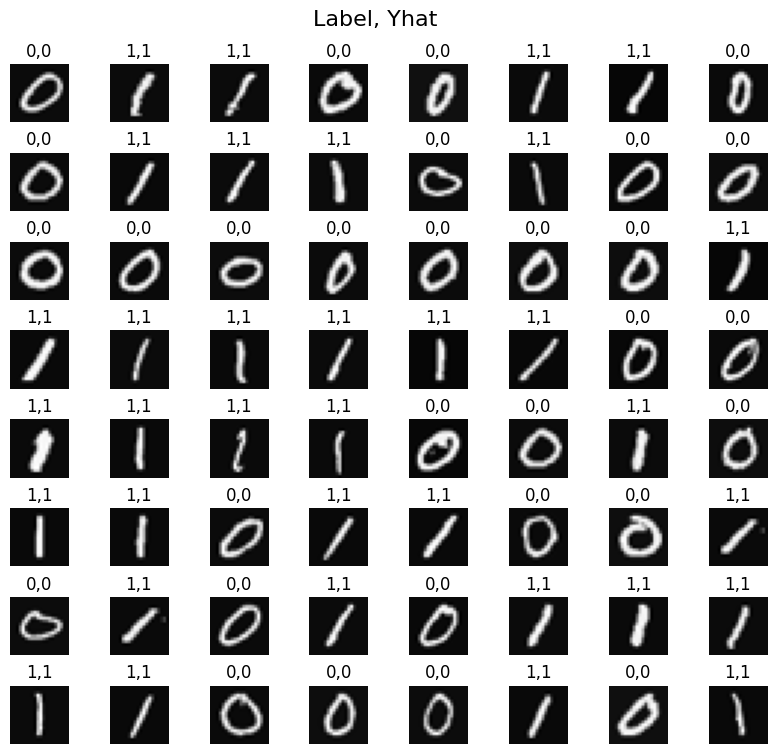

In [91]:
#implement the above

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92])  #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    #select random indices
    random_index = np.random.randint(m)

    #select rows corresponding tothe random indices and reshape the image
    X_random_reshaped = X[random_index].reshape((20, 20)).T

    #display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    #display the label above the image
    ax.set_title(f'{y[random_index,0]},{Yhat[random_index, 0]}')
    ax.set_axis_off()

fig.suptitle(f'Label, Yhat', fontsize=16)
plt.show()

In [ ]:
#mis classified images
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap = 'gray')
plt.title(f'{y[random_index,0]}, {Yhat[random_index, 0]}')
plt.axis('off')
plt.show()